In [1]:
import pandas as pd

df_pats = pd.read_csv("imputation_results_by_patient_FINAL.csv")
print("Registros:", len(df_pats))

Registros: 450


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

mec_labels = {
    'S1': '$Sce_1$',
    'S2': '$Sce_2$',
    'S3': '$Sce_3$',
}

df_pats['mechanism'] = df_pats['mechanism'].map(mec_labels)

imputer_order = ['Mean', 'HT', 'HAT-PH', 'HAT-KSWIN', 'HAT-ADWIN']
mechanism_order = ['$Sce_1$', '$Sce_2$', '$Sce_3$']

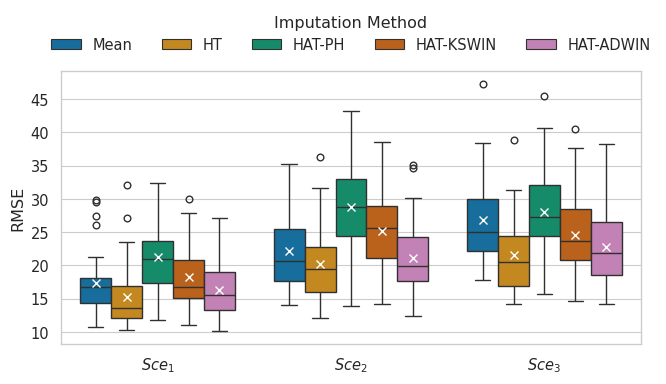

In [ ]:
sns.set_theme(
    style="whitegrid",
    context="paper", 
    font_scale=1.2
)
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_pats,
    x='mechanism',
    y='mean_rmse',
    hue='imputer',
    showmeans=True,
    meanprops={
        "marker": "x",
        "markerfacecolor": "white",
        "markeredgecolor": "white",
        "markersize": 6
    },
    palette='colorblind',
    order=mechanism_order,
    hue_order=imputer_order
)

plt.title('')
plt.xlabel('')
plt.ylabel('RMSE')

plt.legend(
    title='Imputation Method',
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),   
    ncol=len(imputer_order),       
    frameon=False
)

plt.tight_layout()
plt.savefig('Plots/imputation_rmse.png', dpi=300)
plt.show()

CD-Diagrams

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from cd_diagram import draw_cd_diagram

In [3]:
df_pats = pd.read_csv("imputation_results_by_patient_FINAL.csv")

df_crit= df_pats.groupby(['mechanism', 'patient', 'missing_rate', 'imputer'])['mean_rmse'].mean().reset_index()
df_crit['dataset_name'] = df_crit['mechanism'] + '_' + df_crit['patient'] + '_' + df_crit['missing_rate'].astype(str)
df_crit = df_crit.rename(columns={'imputer': 'classifier_name'})
df_crit = df_crit.rename(columns={'mean_rmse': 'accuracy'})
df_crit['accuracy'] = df_crit['accuracy'] * -1
df_crit = df_crit.drop(columns=['patient', 'missing_rate'])
df_crit = df_crit[['classifier_name', 'dataset_name', 'accuracy', 'mechanism']]

df_crit

,classifier_name,dataset_name,accuracy,mechanism
0,HAT-ADWIN,S1_A0NVTRV_30,-12.56,S1
1,HAT-KSWIN,S1_A0NVTRV_30,-13.23,S1
2,HAT-PH,S1_A0NVTRV_30,-12.91,S1
3,HT,S1_A0NVTRV_30,-11.80,S1
4,Mean,S1_A0NVTRV_30,-11.92,S1
...,...,...,...,...
445,HAT-ADWIN,S3_AZIK4ZA_30,-26.97,S3
446,HAT-KSWIN,S3_AZIK4ZA_30,-27.50,S3
447,HAT-PH,S3_AZIK4ZA_30,-32.26,S3
448,HT,S3_AZIK4ZA_30,-24.00,S3


In [4]:
dfs = {}

for mec in df_crit['mechanism'].unique():
    dfs[mec] = df_crit[df_crit['mechanism'] == mec].drop(columns=['mechanism'])

for mec, df_mec in dfs.items():
    draw_cd_diagram(df_perf=df_mec, title=f"{mec_labels[mec]}", labels=False, save_path=f"Plots/CD_Diagrams/CD-{mec}.png")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

['HAT-ADWIN' 'HAT-KSWIN' 'HAT-PH' 'HT' 'Mean']
HAT-ADWIN     6.0
HAT-KSWIN     0.0
HAT-PH        1.0
HT           19.0
Mean          4.0
dtype: float64
HAT-PH       4.666667
HAT-KSWIN    3.333333
Mean         3.000000
HAT-ADWIN    2.350000
HT           1.650000
dtype: float64
('HAT-ADWIN', 'HAT-PH', np.float64(9.313225746154785e-09), True)
('HAT-PH', 'HT', np.float64(2.60770320892334e-08), True)
('HAT-KSWIN', 'HAT-PH', np.float64(1.30385160446167e-07), True)
('HAT-PH', 'Mean', np.float64(2.7623027563095093e-06), True)
('HAT-KSWIN', 'HT', np.float64(3.890545884891091e-05), True)
('HT', 'Mean', np.float64(9.90256667137146e-05), True)
('HAT-ADWIN', 'HAT-KSWIN', np.float64(0.00040325944084334707), True)
('HAT-ADWIN', 'HT', np.float64(0.0029870010912418365), True)
('HAT-ADWIN', 'Mean', np.float64(0.051924464017277704), False)
('HAT-KSWIN', 'Mean', np.float64(0.31351434128194966), False)
Index(['HAT-PH', 'HAT-KSWIN', 'Mean', 'HAT-ADWIN', 'HT'], dtype='object')
[2, 1]
[2, 3]


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

['HAT-ADWIN' 'HAT-KSWIN' 'HAT-PH' 'HT' 'Mean']
HAT-ADWIN     2.0
HAT-KSWIN     2.0
HAT-PH        1.0
HT           20.0
Mean          5.0
dtype: float64
HAT-PH       4.633333
HAT-KSWIN    3.633333
Mean         2.800000
HAT-ADWIN    2.333333
HT           1.600000
dtype: float64
('HAT-PH', 'Mean', np.float64(8.326023817062378e-07), True)
('HAT-KSWIN', 'HT', np.float64(1.6838312149047852e-06), True)
('HAT-PH', 'HT', np.float64(2.1253203734574536e-06), True)
('HAT-ADWIN', 'HAT-PH', np.float64(2.60174464085567e-06), True)
('HAT-KSWIN', 'HAT-PH', np.float64(1.237424352844989e-05), True)
('HAT-ADWIN', 'HAT-KSWIN', np.float64(2.1619387288105737e-05), True)
('HT', 'Mean', np.float64(0.0001528710126876831), True)
('HAT-KSWIN', 'Mean', np.float64(0.0006084088236093521), True)
('HAT-ADWIN', 'HT', np.float64(0.0008304425229287966), True)
('HAT-ADWIN', 'Mean', np.float64(0.006225503508509906), True)
Index(['HAT-PH', 'HAT-KSWIN', 'Mean', 'HAT-ADWIN', 'HT'], dtype='object')
['HAT-ADWIN' 'HAT-KSWIN' 'HA

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

HAT-ADWIN     6.0
HAT-KSWIN     1.0
HAT-PH        0.0
HT           23.0
Mean          0.0
dtype: float64
HAT-PH       4.466667
Mean         4.133333
HAT-KSWIN    3.083333
HAT-ADWIN    1.916667
HT           1.400000
dtype: float64
('HT', 'Mean', np.float64(3.725290298461914e-09), True)
('HAT-ADWIN', 'HAT-PH', np.float64(9.313225746154785e-09), True)
('HAT-PH', 'HT', np.float64(9.313225746154785e-09), True)
('HAT-ADWIN', 'Mean', np.float64(1.7333066441991056e-06), True)
('HAT-KSWIN', 'HT', np.float64(3.879899515846691e-06), True)
('HAT-KSWIN', 'HAT-PH', np.float64(9.220093488693237e-06), True)
('HAT-ADWIN', 'HAT-KSWIN', np.float64(2.2622177348924877e-05), True)
('HAT-KSWIN', 'Mean', np.float64(8.856505155563354e-05), True)
('HAT-ADWIN', 'HT', np.float64(0.00014754846945904334), True)
('HAT-PH', 'Mean', np.float64(0.09194962680339813), False)
Index(['HAT-PH', 'Mean', 'HAT-KSWIN', 'HAT-ADWIN', 'HT'], dtype='object')
[0, 1]


In [ ]:
from PIL import Image

image_files = [f"Plots/CD_Diagrams/CD-{mec}.png" for mec in df_crit['mechanism'].unique()]

images = [Image.open(img_file) for img_file in image_files]

widths, heights = zip(*(img.size for img in images))

total_height = sum(heights)
max_width = max(widths)

combined_image = Image.new('RGB', (max_width, total_height), 'white')

y_offset = 0
for img in images:
    combined_image.paste(img, (0, y_offset))
    y_offset += img.size[1]

combined_image.save('Plots/CD_Diagrams/CD-all-mechanisms.png')
print("Combined image saved as CD-all-mechanisms.png")

Combined image saved as CD-all-mechanisms.png
